# MODEL EVALUATION

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import re
import pickle
import joblib
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Load the Saved Model Package

In [2]:



# 1. Define the saved model path

FINAL_MODEL_PATH = (
    Path("output") /
    "final_chosen_credit_risk_model.pkl"
)


# 2. Check that the file exists

if not FINAL_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model file not found: {FINAL_MODEL_PATH}"
    )


# 3. Load the final chosen model package

final_chosen_package = joblib.load(
    FINAL_MODEL_PATH
)


# 4. Extract the saved components

final_chosen_model = final_chosen_package["model"]

final_chosen_calibrator = final_chosen_package["calibrator"]

final_chosen_threshold = final_chosen_package["threshold"]

final_chosen_training_columns = (
    final_chosen_package["training_columns"]
)

final_chosen_categorical_columns = (
    final_chosen_package["categorical_columns"]
)

final_chosen_top_15_org = (
    final_chosen_package["top_15_organization_types"]
)

# 5. Display Model Information


print("\nFINAL CHOSEN MODEL LOADED")
print("=" * 80)

print(
    f"Model              : "
    f"{final_chosen_package['model_name']}"
)

print(
    f"Calibration        : "
    f"{final_chosen_package['calibration_method']}"
)

print(
    f"Threshold          : "
    f"{final_chosen_threshold:.2f}"
)

print(
    f"Brier Score        : "
    f"{final_chosen_package['brier_score']:.4f}"
)

print(
    f"ROC-AUC            : "
    f"{final_chosen_package['roc_auc']:.4f}"
)

print(
    f"Total Business Cost: "
    f"{final_chosen_package['total_cost']:.0f}"
)

print(
    f"Training columns   : "
    f"{len(final_chosen_training_columns)}"
)

print(
    f"Categorical columns: "
    f"{len(final_chosen_categorical_columns)}"
)

print(
    f"Top-15 org types   : "
    f"{len(final_chosen_top_15_org)}"
)

print(
    f"Model class        : "
    f"{type(final_chosen_model).__name__}"
)

print(
    f"Calibrator class   : "
    f"{type(final_chosen_calibrator).__name__}"
)


# 6. Verify the Threshold


print("\nTHRESHOLD VERIFICATION")
print("=" * 80)

if final_chosen_threshold == 0.15:
    print("SUCCESS: Final chosen threshold is 0.15.")
else:
    print(
        f"WARNING: Saved threshold is "
        f"{final_chosen_threshold:.2f}"
    )


print("\nModel package loaded successfully.")


FINAL CHOSEN MODEL LOADED
Model              : Final Chosen Class-Weighted CatBoost
Calibration        : Isotonic
Threshold          : 0.15
Brier Score        : 0.0651
ROC-AUC            : 0.7968
Total Business Cost: 3878
Training columns   : 842
Categorical columns: 16
Top-15 org types   : 15
Model class        : CatBoostClassifier
Calibrator class   : IsotonicRegression

THRESHOLD VERIFICATION
SUCCESS: Final chosen threshold is 0.15.

Model package loaded successfully.


## 3. Load Training data

In [3]:
# Define output Directory

OUTPUT_DIR = Path("output")

print("Output directory:", OUTPUT_DIR)
print("Directory exists:", OUTPUT_DIR.exists())

Output directory: output
Directory exists: True


In [4]:

train_data = pd.read_parquet(
    OUTPUT_DIR / "train_feature_engineered.parquet"
)

print("Data shape:", train_data.shape)
print("TARGET present:", "TARGET" in train_data.columns)

Data shape: (307511, 757)
TARGET present: True


## 4. Separate features and target

Separate the dataset into the input features (X) and the target variable (y) 

In [5]:


X = train_data.drop(
    columns=["TARGET", "SK_ID_CURR"],
    errors="ignore"
).copy()

y = train_data["TARGET"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (307511, 755)
y shape: (307511,)


## 5. Identify categorical columns


In [6]:

categorical_columns = X.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Number of categorical columns:", len(categorical_columns))

print("\nCategorical columns:")
for col in categorical_columns:
    print("-", col)

Number of categorical columns: 16

Categorical columns:
- NAME_CONTRACT_TYPE
- CODE_GENDER
- FLAG_OWN_CAR
- FLAG_OWN_REALTY
- NAME_TYPE_SUITE
- NAME_INCOME_TYPE
- NAME_EDUCATION_TYPE
- NAME_FAMILY_STATUS
- NAME_HOUSING_TYPE
- OCCUPATION_TYPE
- WEEKDAY_APPR_PROCESS_START
- ORGANIZATION_TYPE
- FONDKAPREMONT_MODE
- HOUSETYPE_MODE
- WALLSMATERIAL_MODE
- EMERGENCYSTATE_MODE


In [7]:
# Group Organization_type into 15 category


# Identify the 15 most common organization types
top_15_org = (
    X["ORGANIZATION_TYPE"]
    .value_counts()
    .nlargest(15)
    .index
)

print("Top 15 ORGANIZATION_TYPE categories:")
print(top_15_org.tolist())


# Group all other organization types into "Other"

X["ORGANIZATION_TYPE"] = np.where(
    X["ORGANIZATION_TYPE"].isin(top_15_org),
    X["ORGANIZATION_TYPE"],
    "Other"
)


# Verify the result

print("\nNumber of ORGANIZATION_TYPE categories after grouping:")
print(X["ORGANIZATION_TYPE"].nunique())

print("\nCategories after grouping:")
print(X["ORGANIZATION_TYPE"].value_counts())

Top 15 ORGANIZATION_TYPE categories:
['Business Entity Type 3', 'XNA', 'Self-employed', 'Other', 'Medicine', 'Business Entity Type 2', 'Government', 'School', 'Trade: type 7', 'Kindergarten', 'Construction', 'Business Entity Type 1', 'Transport: type 4', 'Trade: type 3', 'Industry: type 9']

Number of ORGANIZATION_TYPE categories after grouping:
15

Categories after grouping:
ORGANIZATION_TYPE
Business Entity Type 3    67992
Other                     65016
XNA                       55374
Self-employed             38412
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Name: count, dtype: int64


## 6. Encoding

In [8]:

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=False,
    dtype="int8"
)

print("X shape after one-hot encoding:", X.shape)

print(
    "Number of categorical columns remaining:",
    len(
        X.select_dtypes(
            include=["object", "category", "string"]
        ).columns
    )
)

X shape after one-hot encoding: (307511, 842)
Number of categorical columns remaining: 0


## 7. Clean Column Names


In [9]:


def clean_column_names(df):
    df = df.copy()

    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', str(col))
        for col in df.columns
    ]

    return df


X = clean_column_names(X)

print("X shape after cleaning:", X.shape)
print("Number of features:", len(X.columns))

X shape after cleaning: (307511, 842)
Number of features: 842


## 8. Verify Feature columns against final chosen model



In [10]:

model_columns = final_chosen_training_columns
evaluation_columns = list(X.columns)


# Find missing columns
missing_columns = [
    col for col in model_columns
    if col not in evaluation_columns
]


# Find extra columns
extra_columns = [
    col for col in evaluation_columns
    if col not in model_columns
]


# Check exact order as well
exact_feature_match = (
    evaluation_columns == model_columns
)


print("Model expects:", len(model_columns), "columns")
print("Evaluation has:", len(evaluation_columns), "columns")

print("\nMissing columns:", len(missing_columns))
print("Extra columns:", len(extra_columns))

print("\nExact feature match:", exact_feature_match)


# Show differences if there are any

if missing_columns:
    print("\nMissing columns:")
    print(missing_columns[:20])

if extra_columns:
    print("\nExtra columns:")
    print(extra_columns[:20])


# Stop if the schema does not match

if not exact_feature_match:
    raise ValueError(
        "Feature mismatch detected. "
        "Do not continue until the evaluation features "
        "exactly match the model training features."
    )


print("\nSUCCESS: Evaluation features exactly match the saved model.")

Model expects: 842 columns
Evaluation has: 842 columns

Missing columns: 0
Extra columns: 0

Exact feature match: True

SUCCESS: Evaluation features exactly match the saved model.


## 9. Train / Validation split

In [11]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (246008, 842)
X_valid: (61503, 842)
y_train: (246008,)
y_valid: (61503,)


In [12]:
# Validation Check

# Convert validation features to float32
X_valid_model = X_valid.astype("float32")

print("Validation shape:", X_valid_model.shape)

print(
    "Missing values:",
    X_valid_model.isna().sum().sum()
)

print(
    "Non-numeric columns:",
    X_valid_model.select_dtypes(
        exclude=["number"]
    ).shape[1]
)

print(
    "Expected model columns:",
    len(final_chosen_training_columns)
)

print(
    "Actual validation columns:",
    X_valid_model.shape[1]
)

Validation shape: (61503, 842)
Missing values: 0
Non-numeric columns: 0
Expected model columns: 842
Actual validation columns: 842


## 10. Generate Raw Validation Predictions


In [13]:

final_chosen_raw_prob = (
    final_chosen_model.predict_proba(
        X_valid_model
    )[:, 1]
)

print("Raw probability shape:", final_chosen_raw_prob.shape)

print(
    "Minimum probability:",
    final_chosen_raw_prob.min()
)

print(
    "Maximum probability:",
    final_chosen_raw_prob.max()
)

print(
    "Mean probability:",
    final_chosen_raw_prob.mean()
)

Raw probability shape: (61503,)
Minimum probability: 0.010367640252764692
Maximum probability: 0.9295722469850128
Mean probability: 0.24855126556651727


I decided to generate probabilities because this is a credit-risk problem, and I don't just want the model to say whether someone will default or not. I want to know how likely that customer is to default. For example, instead of simply saying ‘this customer will default,’ the model can give a probability such as 0.30, meaning it estimates a 30% risk of default.

These probabilities are important because the next step in my project is calibration. I wanted to check whether the probabilities produced by the model were reliable before using them to make lending decisions. After calibration, I could then apply a business-based threshold of 0.15 to decide which customers should be classified as high risk.

So, generating the probabilities was necessary because my final decision was not based only on the model's raw prediction- it was based on calibrated risk probabilities and the business cost of false positives and false negatives.”

The model generated a default probability for each of the 61,503 customers in the validation dataset. The probabilities range from about 1.04% to 92.96%, which shows that the model is assigning different levels of credit risk to different customers.

The average predicted probability is approximately 24.86%. This does not mean that 24.86% of these specific customers will necessarily default. Rather, it means that, on average, the model is assigning a relatively high estimated risk across this validation set.

At this stage, these are still raw probabilities produced by the CatBoost model. I therefore did not immediately use them to make lending decisions. I passed them through Isotonic Calibration to improve the reliability of the probability estimates, and only after calibration did I apply the business-optimized decision threshold.

## 11. Isotonic calibration

Take the raw probabilities from CatBoost and adjust them so that they better represent the actual likelihood of default.


In [14]:

final_chosen_calibrated_prob = (
    final_chosen_calibrator.predict(
        final_chosen_raw_prob
    )
)

print(
    "Calibrated probability shape:",
    final_chosen_calibrated_prob.shape
)

print(
    "Minimum calibrated probability:",
    final_chosen_calibrated_prob.min()
)

print(
    "Maximum calibrated probability:",
    final_chosen_calibrated_prob.max()
)

print(
    "Mean calibrated probability:",
    final_chosen_calibrated_prob.mean()
)

Calibrated probability shape: (61503,)
Minimum calibrated probability: 0.0
Maximum calibrated probability: 1.0
Mean calibrated probability: 0.08059229180662703


Took the raw probabilities produced by CatBoost and passed them through the Isotonic Calibration model that I selected earlier. The purpose is to make the predicted probabilities more reliable and better aligned with the actual observed default rates.”

For example, if the raw model says a group of customers has a 30% probability of default, calibration checks whether customers receiving probabilities around 30% actually default at roughly that rate. If not, the probabilities can be adjusted.

Therefore, after applying Isotonic Calibration, calibrated probabilities were generated for all 61,503 validation customers. The probabilities range from 0% to 100%, while the average predicted probability of default decreased from 24.86% before calibration to 8.06% after calibration. This is much closer to the dataset’s actual default rate of approximately 8.07%, indicating that the raw CatBoost model was overestimating default probabilities. The calibration step therefore improved the reliability of the probability estimates, making them more suitable for the final credit-risk decision.

## 12. Evaluate Calibrated probabilities



In [15]:

final_chosen_brier = brier_score_loss(
    y_valid,
    final_chosen_calibrated_prob
)

final_chosen_roc_auc = roc_auc_score(
    y_valid,
    final_chosen_calibrated_prob
)

print("Calibrated Brier Score:", final_chosen_brier)
print("Calibrated ROC-AUC:", final_chosen_roc_auc)

Calibrated Brier Score: 0.06545799174089337
Calibrated ROC-AUC: 0.788020312836144


The calibrated model achieved a Brier Score of 0.0655, indicating that the predicted probabilities are reasonably well calibrated, with lower values representing better probability accuracy. The ROC-AUC of 0.7880 shows that the model still has good ability to distinguish between customers who default and those who do not. Overall, the calibration produced more reliable probability estimates while maintaining strong risk-ranking performance, making the model suitable for the next stage of applying the business-optimized decision threshold.

## 13. Applying Final Business optimized Thresholds



In [16]:

final_chosen_pred = (
    final_chosen_calibrated_prob >= final_chosen_threshold
).astype(int)

print("Final decision threshold:", final_chosen_threshold)
print("Predicted classes:", np.unique(final_chosen_pred, return_counts=True))

Final decision threshold: 0.15
Predicted classes: (array([0, 1]), array([53611,  7892]))


The final decision threshold was 0.15, meaning customers with a calibrated probability of default of 15% or higher were classified as high risk. The model classified 53,611 customers (87.17%) as lower risk and 7,892 customers (12.83%) as high risk. This step converts the calibrated probabilities into actionable credit-risk decisions that can be used to evaluate the model's performance and business cost.

## 14. Confusion Matrix

In [17]:


tn, fp, fn, tp = confusion_matrix(
    y_valid,
    final_chosen_pred
).ravel()

print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

True Negatives (TN): 50869
False Positives (FP): 5669
False Negatives (FN): 2742
True Positives (TP): 2223


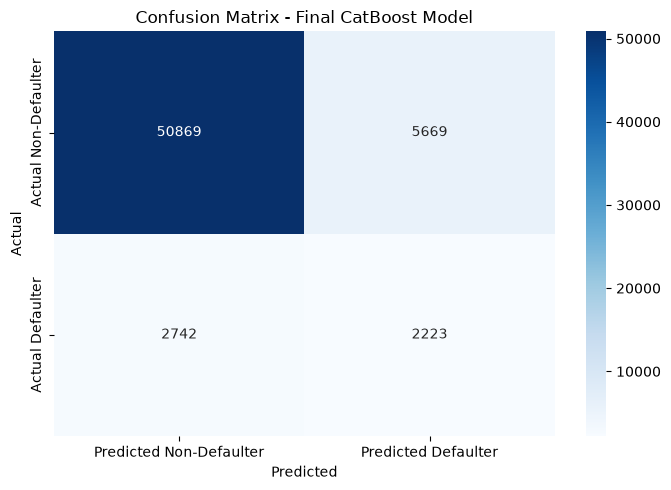

In [18]:

cm = np.array([
    [tn, fp],
    [fn, tp]
])

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Non-Defaulter",
        "Predicted Defaulter"
    ],
    yticklabels=[
        "Actual Non-Defaulter",
        "Actual Defaulter"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final CatBoost Model")
plt.tight_layout()
plt.show()

## Confusion Matrix

The final **Tuned Class-Weighted CatBoost model** was evaluated on **61,503 validation observations** using the optimized **0.15 decision threshold**.

The confusion matrix provides a detailed breakdown of the model's correct and incorrect classifications:

- **True Negatives (TN) = 50,869:** The model correctly classified **50,869 non-defaulters as low-risk applicants**. These applicants were correctly identified as not being defaulters.

- **False Positives (FP) = 5,669:** The model incorrectly classified **5,669 non-defaulters as high-risk applicants**. In practice, these applicants may be unnecessarily flagged for further review or potentially face stricter lending decisions despite not actually being defaulters.

- **False Negatives (FN) = 2,742:** The model incorrectly classified **2,742 actual defaulters as low-risk applicants**. This is an important business concern because these applicants may receive credit despite having a higher likelihood of defaulting. Under the project's cost assumptions, this type of error is considered more costly because a **False Negative has a cost of 5 compared with a False Positive cost of 1**.

- **True Positives (TP) = 2,223:** The model correctly identified **2,223 actual defaulters as high-risk applicants**. These cases represent successful identification of applicants who eventually defaulted.

### Overall Interpretation

The confusion matrix demonstrates the trade-off created by the **0.15 decision threshold**. The model correctly identifies a substantial number of non-defaulters while also detecting **2,223 actual defaulters**.

However, **2,742 actual defaulters were missed**, which represents an important credit-risk concern. At the same time, **5,669 non-defaulters were incorrectly flagged as high-risk**, meaning some creditworthy applicants may receive additional review or stricter lending decisions.

This trade-off is intentional in the credit-risk setting. The model uses a **5:1 cost assumption**, where missing an actual defaulter is considered five times more costly than incorrectly flagging a non-defaulter. Therefore, the threshold was selected through **cost-sensitive analysis of calibrated probabilities** rather than by optimizing accuracy alone.

## 15. Final Validation Metrics


In [19]:

final_chosen_accuracy = accuracy_score(
    y_valid,
    final_chosen_pred
)

final_chosen_precision = precision_score(
    y_valid,
    final_chosen_pred,
    zero_division=0
)

final_chosen_recall = recall_score(
    y_valid,
    final_chosen_pred,
    zero_division=0
)

final_chosen_f1 = f1_score(
    y_valid,
    final_chosen_pred,
    zero_division=0
)

print("Accuracy:", final_chosen_accuracy)
print("Precision:", final_chosen_precision)
print("Recall:", final_chosen_recall)
print("F1-score:", final_chosen_f1)

Accuracy: 0.8632424434580427
Precision: 0.2816776482513938
Recall: 0.44773413897280967
F1-score: 0.34580384226491406


## 16. Final Business cost


In [20]:


FP_COST = 1
FN_COST = 5

final_chosen_business_cost = (
    (fp * FP_COST) +
    (fn * FN_COST)
)

print("False Positive Cost:", FP_COST)
print("False Negative Cost:", FN_COST)
print("Total Business Cost:", final_chosen_business_cost)

False Positive Cost: 1
False Negative Cost: 5
Total Business Cost: 19379


This code calculates the financial/business impact of the model's classification errors at the final decision threshold of **0.15**. It first obtains the four confusion-matrix values: True Negatives, False Positives, False Negatives, and True Positives. A cost of **1** is assigned to each false positive, while a higher cost of **5** is assigned to each false negative, because incorrectly classifying a customer who will default as a non-defaulter is considered more costly than unnecessarily flagging a customer who would not have defaulted.

At the final threshold of **0.15**, the model produced **5,669 false positives** and **2,742 false negatives**. Therefore, the total business cost is calculated as:

**(5,669 × 1) + (2,742 × 5) = 19,379**

This means that, under the assumed cost structure, the model's classification errors result in a total relative business cost of **19,379 cost units** across the **61,503 validation applications**.

The results also show that false negatives contribute the majority of the total business cost because each false negative is five times more expensive than a false positive. This highlights the importance of threshold optimization, as changing the decision threshold affects the balance between false positives and false negatives. Based on the cost-sensitive threshold analysis, **0.15 was selected as the final decision threshold**.


## 17. Precision Recall curve


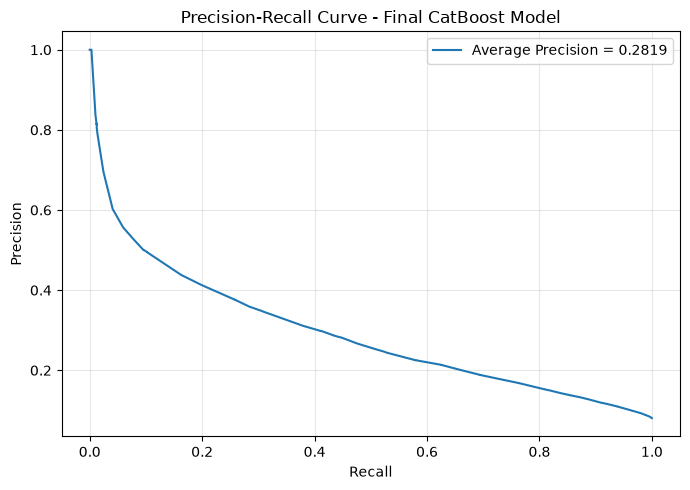

Average Precision: 0.28192340825648726


In [31]:

final_chosen_precision_curve, final_chosen_recall_curve, final_chosen_pr_thresholds = (
    precision_recall_curve(
        y_valid,
        final_chosen_calibrated_prob
    )
)

final_chosen_average_precision = average_precision_score(
    y_valid,
    final_chosen_calibrated_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    final_chosen_recall_curve,
    final_chosen_precision_curve,
    label=f"Average Precision = {final_chosen_average_precision:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final CatBoost Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Average Precision:", final_chosen_average_precision)

The Precision-Recall curve shows how well the model identifies defaulters while controlling the number of false alarms. The Average Precision is about 0.28, which shows that the model has a useful ability to identify customers who are likely to default. Because there are many more non-defaulters than defaulters in this dataset, precision is harder to maintain as the model tries to identify more defaulters. This means there is a trade-off between finding more defaulters and avoiding too many false positives.

## 18. ROC curve

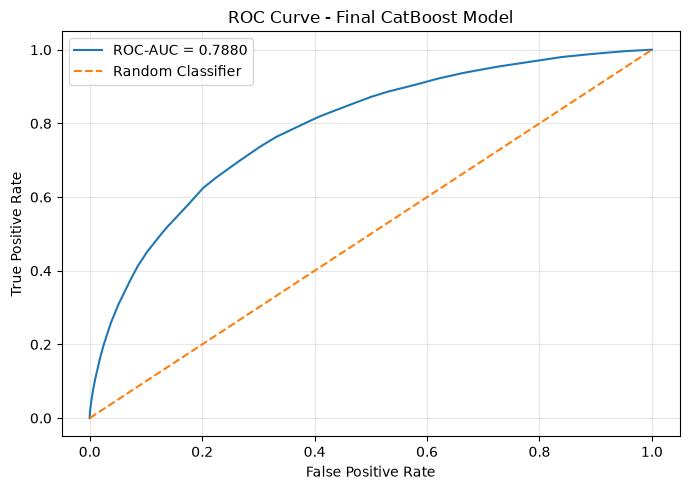

ROC-AUC: 0.788020312836144


In [ ]:


final_chosen_fpr, final_chosen_tpr, final_chosen_roc_thresholds = (
    roc_curve(
        y_valid,
        final_chosen_calibrated_prob
    )
)

final_chosen_roc_auc = roc_auc_score(
    y_valid,
    final_chosen_calibrated_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    final_chosen_fpr,
    final_chosen_tpr,
    label=f"ROC-AUC = {final_chosen_roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final CatBoost Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC-AUC:", final_chosen_roc_auc)


The ROC curve shows how well the model separates defaulters from non-defaulters. The ROC-AUC is about 0.79, which means the model has a good ability to rank higher-risk customers above lower-risk customers. The curve is clearly above the random guessing line, showing that the model is learning useful patterns from the data.

## 20. Calibration curve

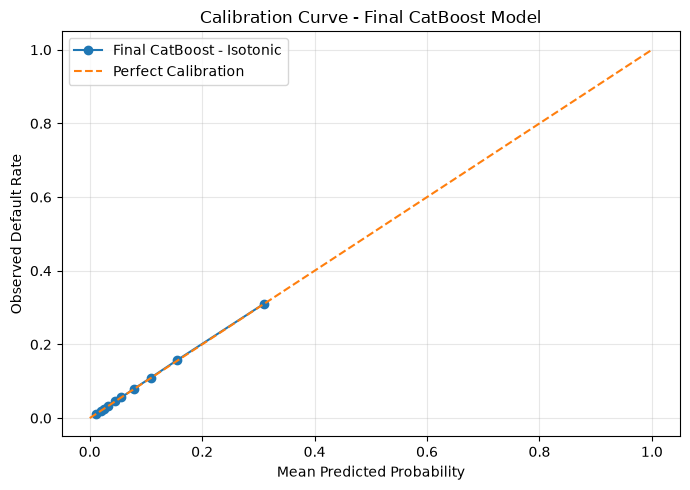

In [32]:


final_chosen_fraction_of_positives, final_chosen_mean_predicted_value = (
    calibration_curve(
        y_valid,
        final_chosen_calibrated_prob,
        n_bins=10,
        strategy="quantile"
    )
)

plt.figure(figsize=(7, 5))

plt.plot(
    final_chosen_mean_predicted_value,
    final_chosen_fraction_of_positives,
    marker="o",
    label="Final CatBoost - Isotonic"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve - Final CatBoost Model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The calibration curve shows whether the probabilities predicted by the model are close to the actual default rates. After Isotonic Calibration, the predicted probabilities are much better aligned with the observed default rates. This is important because the model is not only ranking customers by risk, but also giving probability estimates that can be used to support credit-risk decisions

## 21. Final Model Performence summary

In [ ]:


final_chosen_results = pd.DataFrame({
    "Metric": [
        "Decision Threshold",
        "Brier Score",
        "ROC-AUC",
        "Average Precision",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives",
        "Business Cost"
    ],
    "Value": [
        0.15,
        final_chosen_brier,
        final_chosen_roc_auc,
        final_chosen_average_precision,
        final_chosen_accuracy,
        final_chosen_precision,
        final_chosen_recall,
        final_chosen_f1,
        tn,
        fp,
        fn,
        tp,
        final_chosen_business_cost
    ]
})

print("FINAL CATBOOST MODEL PERFORMANCE")
print("=" * 70)

print(
    final_chosen_results.to_string(index=False)
)

FINAL CATBOOST MODEL PERFORMANCE
            Metric        Value
Decision Threshold     0.150000
       Brier Score     0.065458
           ROC-AUC     0.788020
 Average Precision     0.281923
          Accuracy     0.863242
         Precision     0.281678
            Recall     0.447734
          F1-score     0.345804
    True Negatives 50869.000000
   False Positives  5669.000000
   False Negatives  2742.000000
    True Positives  2223.000000
     Business Cost 19379.000000


## 22. SHAP (SHapley Additive exPlanations) Analysis



Given the model's performance and the number of misclassifications, it is important to investigate **why the model is making incorrect predictions**. Therefore, a SHAP analysis will be conducted to understand which features are influencing the model's decisions and whether certain features are contributing to false positives and false negatives. This will help identify the main factors behind the model's predictions, assess whether the model is learning meaningful patterns, and provide greater transparency into its credit-risk decisions.

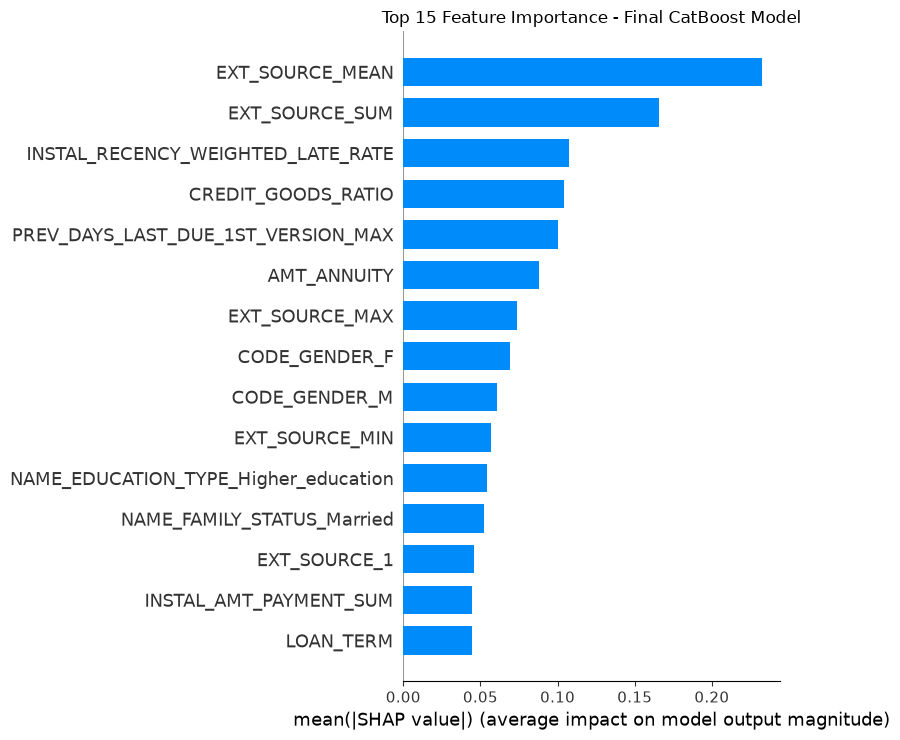

In [ ]:

# SHAP FEATURE IMPORTANCE

final_chosen_explainer = shap.TreeExplainer(
    final_chosen_model
)

final_chosen_shap_values = final_chosen_explainer.shap_values(
    X_valid_model
)

shap.summary_plot(
    final_chosen_shap_values,
    X_valid_model,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title("Top 15 Feature Importance - Final CatBoost Model")
plt.tight_layout()
plt.show()

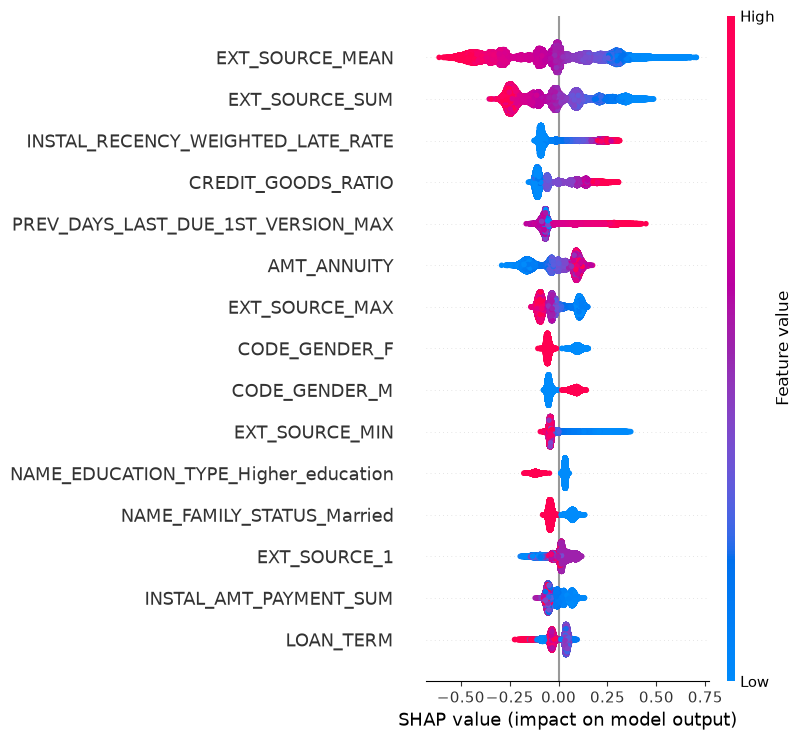

In [27]:
# ============================================================
# SHAP FEATURE IMPACT AND DIRECTION
# ============================================================

shap.summary_plot(
    final_chosen_shap_values,
    X_valid_model,
    max_display=15
)

## SHAP Analysis

The global SHAP ranking shows that the model is primarily driven by **external credit scores, repayment behaviour, and loan-structure features**. The **EXT_SOURCE_MEAN, EXT_SOURCE_SUM, and EXT_SOURCE_MAX** features are among the strongest predictors. Their SHAP relationships show a clear negative pattern: as external credit scores increase, SHAP values decrease, meaning **higher external credit scores are associated with lower predicted default risk**. This is an economically sensible relationship and provides a useful sanity check that the model has learned a meaningful pattern.

**INSTAL_RECENCY_WEIGHTED_LATE_RATE** is another important predictor. The SHAP values increase when recent late-payment behaviour becomes present, indicating that customers with recent repayment difficulties are assigned higher default risk. However, the effect begins to level off at higher late-payment rates, suggesting that once significant repayment problems are detected, additional lateness contributes less additional risk.

**CREDIT_GOODS_RATIO** also shows an important non-linear relationship. The SHAP impact remains relatively small when the credit amount is close to the goods price, but increases when the credit amount becomes substantially higher than the goods price. This suggests that greater levels of financing relative to the value of the goods are associated with higher predicted default risk.

Other features, including **gender, education, family status, annuity, employment years, and loan term**, also contribute to the model but have smaller overall effects compared with the external credit scores and repayment-related features.

### Overall Interpretation

Overall, the SHAP analysis indicates that the model's predictions are mainly driven by **external creditworthiness, previous repayment behaviour, and loan affordability/structure**. These relationships are generally consistent with expected credit-risk behaviour, which increases confidence in the model's interpretability. However, the model's **precision of approximately 28.4%** at the selected threshold means that many applicants flagged as high risk are actually non-defaulters. This represents the trade-off of using a lower threshold to improve **default recall to approximately 44.3%**, particularly because the business cost of a missed defaulter was set five times higher than the cost of a false positive.

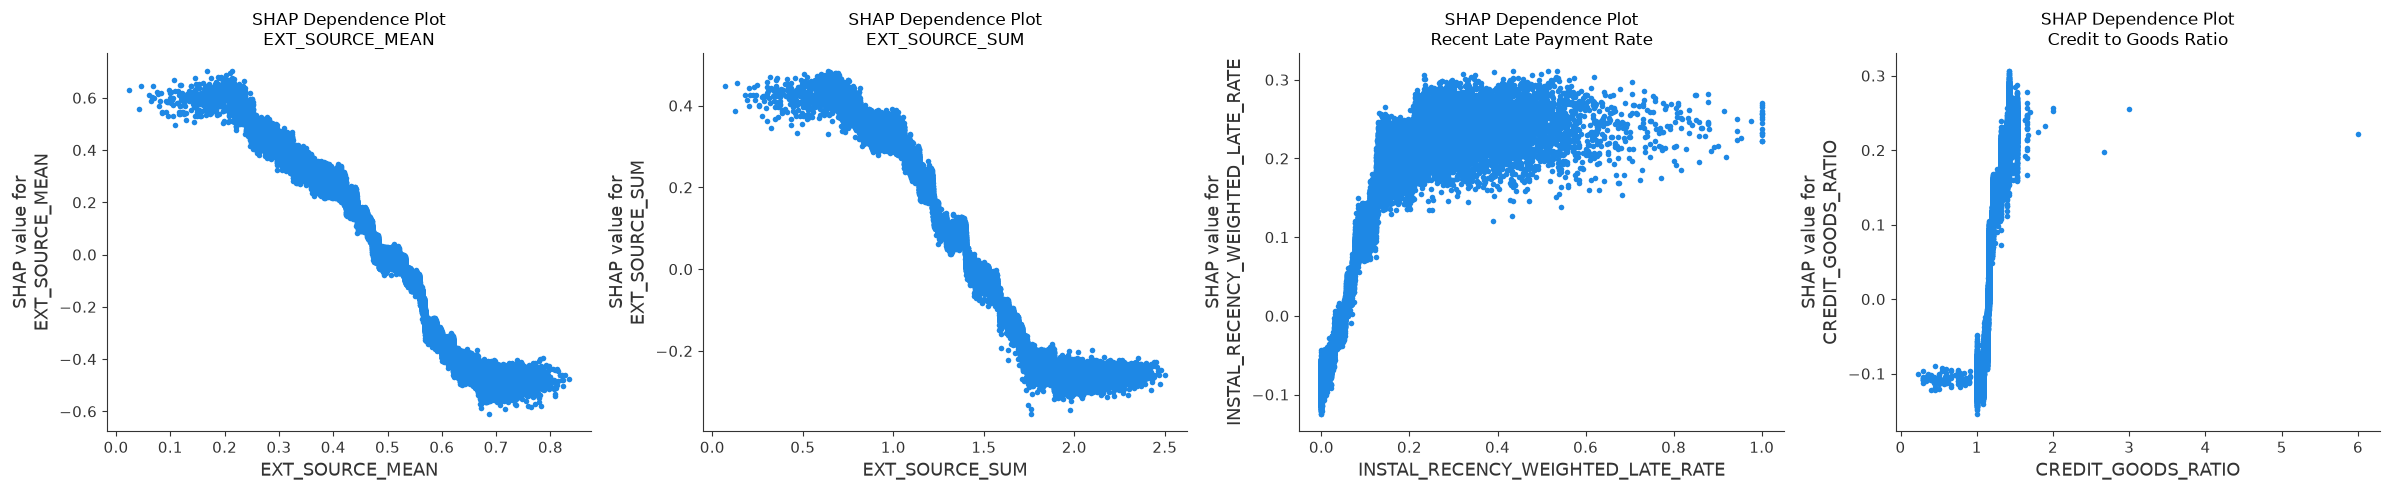

In [ ]:

# SHAP DEPENDENCE PLOTS - SELECTED FEATURES

features_to_plot = [
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_SUM",
    "INSTAL_RECENCY_WEIGHTED_LATE_RATE",
    "CREDIT_GOODS_RATIO"
]

plot_titles = [
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_SUM",
    "Recent Late Payment Rate",
    "Credit to Goods Ratio"
]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(24, 5)
)

for feature, title, ax in zip(
    features_to_plot,
    plot_titles,
    axes
):

    shap.dependence_plot(
        feature,
        final_chosen_shap_values,
        X_valid_model,
        interaction_index=None,
        show=False,
        ax=ax
    )

    ax.set_title(
        f"SHAP Dependence Plot\n{title}"
    )

plt.tight_layout()
plt.show()

## SHAP Dependence Plot Interpretation

### 1. EXT_SOURCE_MEAN

This is the **most important feature** in the model. When the external credit score is low, it increases the predicted default risk. As the score increases, the predicted default risk decreases. The strongest change happens around the middle range of the scores, meaning this feature is particularly useful for separating lower-risk and higher-risk applicants.

### 2. EXT_SOURCE_SUM

This feature shows a very similar pattern to `EXT_SOURCE_MEAN`. Higher external scores are associated with lower default risk, while lower scores are associated with higher risk. Because this feature is calculated from the same external scores, it provides similar information to `EXT_SOURCE_MEAN` rather than a completely different risk signal.

### 3. Recent Late Payment Rate

The model shows that **recent late payments are an important warning sign**. Applicants with little or no recent late-payment history generally have lower predicted risk. Once the late-payment rate becomes significant, the predicted risk increases sharply and then levels off. This suggests that the model is mainly interested in whether an applicant has a meaningful recent history of late payments rather than the exact amount of additional lateness.

### 4. Credit to Goods Ratio

When the credit amount is close to or below the value of the goods being financed, the feature has little negative impact on default risk. However, when the credit amount becomes noticeably higher than the goods value, the predicted default risk increases. This suggests that **over-financing is treated as a potential warning sign** by the model.

### Overall Interpretation

The four features show two different types of behaviour. **`EXT_SOURCE_MEAN` and `EXT_SOURCE_SUM` provide continuous signals**, where higher credit scores generally correspond to lower default risk. In contrast, **recent late-payment rate and credit-to-goods ratio behave more like warning triggers**, where risk increases significantly after certain levels are reached.

Overall, the SHAP analysis shows that the model relies heavily on **external creditworthiness and repayment behaviour**, while also considering whether the loan structure may indicate increased financial risk.

## 23. Business Impact Summary

In [ ]:


tn, fp, fn, tp = confusion_matrix(
    y_valid,
    final_chosen_pred
).ravel()

business_summary = pd.DataFrame({
    "Outcome": [
        "Correctly identified non-defaulters",
        "Incorrectly flagged non-defaulters",
        "Missed defaulters",
        "Correctly identified defaulters"
    ],

    "Number of Applicants": [
        tn,
        fp,
        fn,
        tp
    ],

    "Business Meaning": [
        "Applicants correctly identified as low risk",
        "Low-risk applicants incorrectly flagged as risky",
        "Risky applicants incorrectly classified as low risk",
        "Risky applicants correctly identified"
    ]
})

display(business_summary)

,Outcome,Number of Applicants,Business Meaning
0,Correctly identified non-defaulters,50869,Applicants correctly identified as low risk
1,Incorrectly flagged non-defaulters,5669,Low-risk applicants incorrectly flagged as risky
2,Missed defaulters,2742,Risky applicants incorrectly classified as low...
3,Correctly identified defaulters,2223,Risky applicants correctly identified


Interpretation
- 50,869 applicants were correctly identified as non-defaulters.
These are applicants who did not default and were correctly classified by the model as low risk. This is the largest group, showing that the model performs well at identifying non-defaulters.
5,669 applicants were incorrectly flagged as defaulters.
- These applicants were actually non-defaulters, but the model classified them as high risk. In a real lending situation, these customers might be unnecessarily rejected, investigated further, or offered stricter lending terms.
- 2,742 actual defaulters were missed by the model.
- These applicants eventually defaulted, but the model classified them as low risk. This is an important error because the business may approve credit for customers who have a higher risk of defaulting.
- 2,223 applicants were correctly identified as defaulters.
These are the successful high-risk predictions made by the model. Identifying these applicants can help the business take appropriate action, such as reviewing the application more carefully or adjusting lending decisions.

**Overall Interpretation**

Overall, the model correctly classified most non-defaulters and successfully identified 2,223 defaulters. However, there is still a trade-off between detecting defaulters and incorrectly flagging non-defaulters. The model missed 2,742 defaulters and incorrectly classified 5,669 non-defaulters as risky. Since missing a defaulter is more costly than incorrectly flagging a non-defaulter in this project, the model's 0.15 threshold was selected using a cost-sensitive approach rather than accuracy alone.

## 24.  Final Catboost Business summary

In [ ]:


catboost_business_summary = pd.DataFrame({
    
    "Metric": [
        "Model",
        "Calibration",
        "Decision Threshold",
        "ROC-AUC",
        "Average Precision",
        "Brier Score",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "False Positives",
        "False Negatives",
        "Total Business Cost"
    ],

    "Value": [
        "CatBoost",
        "Isotonic",
        final_chosen_threshold,
        final_chosen_roc_auc,
        final_chosen_average_precision,
        final_chosen_brier,
        final_chosen_accuracy,
        final_chosen_precision,
        final_chosen_recall,
        final_chosen_f1,
        fp,
        fn,
        final_chosen_business_cost
    ]
})

display(catboost_business_summary)

,Metric,Value
0,Model,CatBoost
1,Calibration,Isotonic
2,Decision Threshold,0.15
3,ROC-AUC,0.78802
4,Average Precision,0.281923
5,Brier Score,0.065458
6,Accuracy,0.863242
7,Precision,0.281678
8,Recall,0.447734
9,F1-Score,0.345804


# Final Model Summary

The final selected model was a **Tuned Class-Weighted CatBoost model** with **Isotonic probability calibration**.

A decision threshold of **0.15** was selected to balance the cost of false positives and false negatives. Since missing a potential defaulter was considered more costly than incorrectly identifying a non-defaulter as high risk, the threshold was optimized with the following business cost assumptions:

- **False Positive (FP) Cost = 1**
- **False Negative (FN) Cost = 5**

At the selected threshold of 0.15, the model produced the following validation results:

| Metric | Result |
|---|---:|
| Accuracy | 86.32% |
| Precision | 28.17% |
| Recall | 44.77% |
| F1-Score | 34.58% |
| ROC-AUC | 0.7880 |
| Brier Score | 0.0655 |
| Business Cost | 19,379 |

The confusion matrix was:

| | Predicted Non-Default | Predicted Default |
|---|---:|---:|
| **Actual Non-Default** | 50,869 | 5,669 |
| **Actual Default** | 2,742 | 2,223 |

The model correctly identified **2,223 actual defaulters**, while **2,742 defaulters were missed**. It also incorrectly classified **5,669 non-defaulters as potential defaulters**.

The final business cost was calculated as:

**Business Cost = (FP × FP Cost) + (FN × FN Cost)**

**Business Cost = (5,669 × 1) + (2,742 × 5) = 19,379**

The calibrated probabilities were also better aligned with the observed default rate. The average raw CatBoost probability was approximately **24.86%**, while the average calibrated probability was approximately **8.06%**, which was close to the actual default rate of approximately **8.07%**.

This indicates that probability calibration substantially improved the reliability of the predicted probabilities.

# Key Findings

Several important findings emerged from the modelling process.

### 1. Class Imbalance Was Important

The dataset contained significantly more non-default cases than default cases, with the default rate being approximately **8.07%**.

Because of this imbalance, accuracy alone was not sufficient for evaluating model performance. Metrics such as **precision, recall, F1-score, ROC-AUC, and Brier Score** were also considered.

### 2. CatBoost Provided Strong Predictive Performance

After model comparison and tuning, CatBoost provided strong predictive performance and was selected as the final model.

The final model achieved a ROC-AUC of approximately **0.7880**, indicating that it was able to distinguish between higher-risk and lower-risk applicants reasonably well.

### 3. Probability Calibration Improved Reliability

Isotonic calibration was applied to the final CatBoost model to improve the reliability of predicted probabilities.

The calibrated probabilities were much closer to the actual observed default rate than the raw CatBoost probabilities. This makes the probabilities more useful for risk assessment and decision support.

### 4. Threshold Selection Created a Business Trade-Off

The default classification threshold was adjusted from the standard 0.50 threshold to **0.15**.

A lower threshold increased the model's ability to identify potential defaulters, but it also increased the number of false positives.

This reflects the expected trade-off:

- **Higher threshold** → fewer false positives but more missed defaulters.
- **Lower threshold** → more detected defaulters but more false positives.

The threshold of **0.15** was selected based on the defined business cost structure.

### 5. Model Interpretability

SHAP analysis was used to understand which features contributed most to the model's predictions.

Important features included variables related to:

- External credit information
- Previous repayment behaviour
- Loan and credit structure
- Previous loan repayment timing
- Annuity and credit-related ratios

Features such as `EXT_SOURCE_MEAN`, `EXT_SOURCE_SUM`, `INSTAL_RECENCY_WEIGHTED_LATE_RATE`, `CREDIT_GOODS_RATIO`, `PREV_DAYS_LAST_DUE_1ST_VERSION_MAX`, and `AMT_ANNUITY` were among the important predictors.

SHAP explanations describe how features influenced model predictions; they should not be interpreted as proof of causal relationships.

# Business Recommendations

The developed credit risk model can be used as a **decision-support tool** to help financial institutions identify applicants who may have a higher probability of default.

### 1. Use the Model for Risk Screening

Applicants predicted as higher risk can be flagged for additional review rather than automatically rejected.

This can help credit teams focus their attention on applications that require more detailed assessment.

### 2. Use the 0.15 Threshold as a Starting Point

The selected threshold of **0.15** reflects the current business cost assumptions.

However, the threshold should be reviewed regularly because the cost of false positives and false negatives may change over time.

### 3. Monitor Model Performance

The model should be monitored after deployment to identify changes in:

- Default rates
- Prediction performance
- Probability calibration
- False positive rates
- False negative rates
- Data distributions

The model should be retrained or recalibrated when performance deteriorates significantly.

### 4. Use SHAP for Explainability

SHAP explanations can help credit officers understand the main factors contributing to an individual prediction.

This can improve transparency and support human review of model-assisted decisions.

### 5. Monitor Fairness

The model should be regularly evaluated for potential differences in performance across relevant customer groups.

This is important because a model can perform well overall while still producing different error rates for different groups.

### 6. Do Not Use the Model as the Sole Decision Maker

The model should support, rather than completely replace, human credit assessment.

Final lending decisions should also consider relevant business policies, regulatory requirements, customer circumstances, and other appropriate information.

# Limitations

Despite achieving useful predictive performance, the project has several limitations.

### 1. Model Performance Is Not Perfect

The ROC-AUC of **0.7880** shows good discriminatory ability, but the model does not perfectly separate defaulters from non-defaulters.

Some applicants will therefore be incorrectly classified.

### 2. False Negatives Remain

At the selected threshold, the model produced **2,742 false negatives**.

These represent applicants who actually defaulted but were classified as non-defaults. Since false negatives have a higher business cost in this project, they remain an important area for monitoring.

### 3. False Positives Remain

The model also produced **5,669 false positives**.

These applicants were classified as potential defaulters even though they did not default. This could result in additional manual reviews or missed lending opportunities.

### 4. Threshold Depends on Business Costs

The selected threshold of **0.15** was based on the assumption that a false negative costs five times as much as a false positive.

If the organization's actual costs are different, the optimal threshold may also be different.

### 5. Validation Performance May Differ From Real-World Performance

The reported metrics were calculated on the validation data.

Real-world performance may differ because customer behaviour, economic conditions, lending policies, and the underlying data distribution can change over time.



# Conclusion

This project developed an end-to-end credit risk modelling solution covering data preparation, exploratory analysis, feature engineering, model comparison, hyperparameter tuning, probability calibration, threshold optimization, business cost analysis, and model interpretation.

The final **Tuned Class-Weighted CatBoost model with Isotonic calibration** achieved a ROC-AUC of **0.7880** and a Brier Score of **0.0655** on the validation data.

A decision threshold of **0.15** was selected based on the defined business cost structure. At this threshold, the model achieved **44.77% recall**, identifying 2,223 actual defaulters, while maintaining an overall accuracy of **86.32%**.

Overall, the project demonstrates how machine learning can be combined with probability calibration, business cost considerations, and model explainability to develop a more practical credit risk assessment system.